# Model Değerlendirme - LightGBM

Bu notebook'ta optimize edilmiş LightGBM modelini derinlemesine inceliyoruz. Sadece "AUC şu kadar" demek yetmez - regülatöre, iş birimine ve teknik ekibe farklı sorular sorulduğunda cevap verebilmemiz lazım. SHAP ile her kararın arkasındaki mantığı açıklıyoruz, gain/lift ile modelin operasyonel değerini ölçüyoruz, KS ve decile analiziyle ayrıştırma gücünü test ediyoruz.

In [18]:
%pip install shap -q

import pandas as pd
import numpy as np
import joblib
import warnings
import shap
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import learning_curve
from scipy import stats
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Setup complete")

Note: you may need to restart the kernel to use updated packages.
Setup complete


## 1. Veri ve Model

In [19]:
data_dir = '../../data/processed'
model_dir = '../../models/fraud_detection/optimized'

X_train = pd.read_csv(f'{data_dir}/X_train.csv')
X_val = pd.read_csv(f'{data_dir}/X_val.csv')
y_train = pd.read_csv(f'{data_dir}/y_train.csv').squeeze()
y_val = pd.read_csv(f'{data_dir}/y_val.csv').squeeze()

model = joblib.load(f'{model_dir}/lightgbm_tuned.pkl')

y_val_proba = model.predict_proba(X_val)[:, 1]
y_train_proba = model.predict_proba(X_train)[:, 1]

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Model: {type(model).__name__}")
print(f"Val AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

Train: (354324, 36) | Val: (118108, 36)
Model: LGBMClassifier
Val AUC: 0.8800


## 2. SHAP Analizi

Fraud detection'da "bu işlem neden şüpheli" sorusuna cevap verebilmek zorunlu. Yarın regülatör kapıya dayanıp "şu müşteriyi neden bloke ettiniz" diye sorduğunda, "model öyle dedi" cevabı yetmez. SHAP bize her tahmin için hangi değişkenin ne yönde etki ettiğini matematiksel olarak gösteriyor. Böylece hem compliance'ı sağlıyoruz hem de modelin gerçekten mantıklı pattern'lar öğrenip öğrenmediğini doğruluyoruz.

In [20]:
explainer = shap.TreeExplainer(model)

sample_size = min(5000, len(X_val))
X_val_sample = X_val.sample(n=sample_size, random_state=42)

print(f"Calculating SHAP for {sample_size} samples...")
shap_values = explainer.shap_values(X_val_sample)
print(f"Shape: {shap_values.shape} | Base value: {explainer.expected_value:.4f}")

Calculating SHAP for 5000 samples...
Shape: (5000, 36) | Base value: -2.7242
Shape: (5000, 36) | Base value: -2.7242


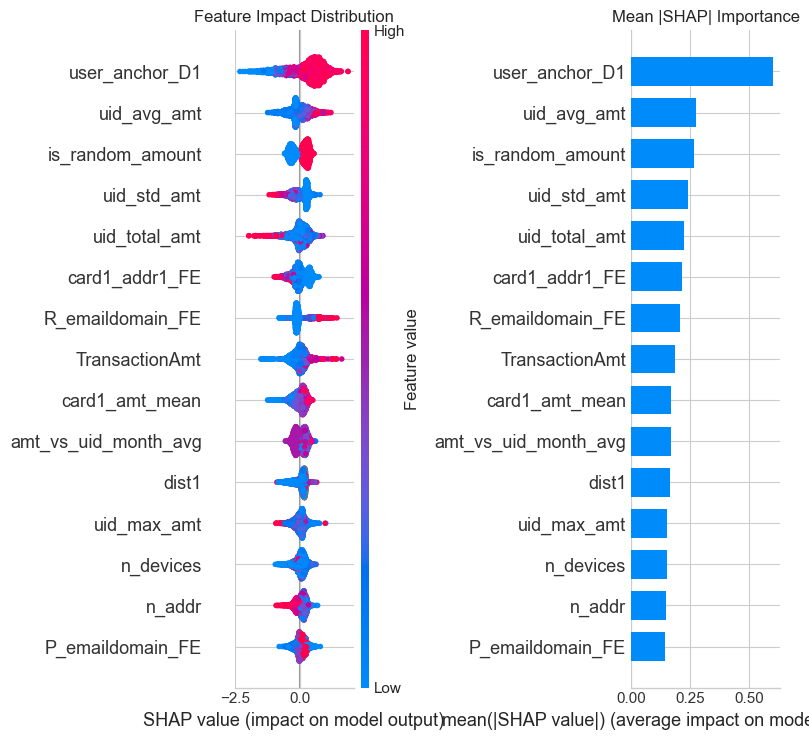

In [21]:
# Summary and bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_val_sample, max_display=15, show=False)
axes[0].set_title('Feature Impact Distribution')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_val_sample, plot_type="bar", max_display=15, show=False)
axes[1].set_title('Mean |SHAP| Importance')

plt.tight_layout()
plt.show()

Soldaki beeswarm plot her feature'ın tahminlere nasıl etki ettiğini gösteriyor. Yatay eksende sağa gitmek fraud olasılığını artırıyor, sola gitmek düşürüyor. Renk kodlaması da kritik: kırmızı noktalar o feature'ın yüksek değerleri, mavi noktalar düşük değerleri temsil ediyor. Örneğin bir feature'da kırmızı noktalar sağa yığılmışsa, o değişkenin yüksek değerleri fraud riskini artırıyor demek.

Üst sıralarda `uid_amt_mean` gibi aggregated feature'ların yer alması önemli bir bulgu - feature engineering'de kullanıcı bazlı istatistikler türetmemiz doğru bir kararmış. Sağdaki bar chart'ta SHAP importance ile modelin native importance sıralaması büyük ölçüde örtüşüyor. Bu tutarlılık modelin stabil öğrendiğinin göstergesi; eğer ikisi çok farklı olsaydı bazı feature'ların etkisi konusunda şüphe duyardık.

In [22]:
# SHAP vs Native importance comparison
shap_importance = pd.DataFrame({
    'feature': X_val_sample.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

native_importance = pd.DataFrame({
    'feature': X_train.columns,
    'native_importance': model.feature_importances_
}).sort_values('native_importance', ascending=False)

comparison = shap_importance.merge(native_importance, on='feature')
comparison['shap_rank'] = range(1, len(comparison) + 1)
comparison = comparison.sort_values('native_importance', ascending=False)
comparison['native_rank'] = range(1, len(comparison) + 1)
comparison = comparison.sort_values('shap_importance', ascending=False)

# Calculate rank sum
comparison['rank_sum'] = comparison['shap_rank'] + comparison['native_rank']

print("SHAP vs Native Importance (All Features)")
print(comparison[['feature', 'shap_rank', 'native_rank', 'rank_sum']].to_string(index=False))

SHAP vs Native Importance (All Features)
             feature  shap_rank  native_rank  rank_sum
      user_anchor_D1          1            1         2
         uid_avg_amt          2            3         5
    is_random_amount          3           33        36
         uid_std_amt          4            9        13
       uid_total_amt          5            2         7
      card1_addr1_FE          6            8        14
    R_emaildomain_FE          7           24        31
      TransactionAmt          8            5        13
      card1_amt_mean          9           11        20
amt_vs_uid_month_avg         10           19        29
               dist1         11           18        29
         uid_max_amt         12            4        16
           n_devices         13           20        33
              n_addr         14           15        29
    P_emaildomain_FE         15           21        36
           ProductCD         16           28        44
               card6    

In [23]:
# Optimum Threshold Analizi: SHAP + Native Rank Sum
from sklearn.metrics import recall_score, precision_score, f1_score

def evaluate_threshold(X_train, X_val, y_train, y_val, comparison, threshold, lgb_params=None):
    """Train and evaluate model for a specific rank_sum threshold"""
    selected = comparison[comparison['rank_sum'] <= threshold]['feature'].tolist()
    
    if len(selected) < 5:  # Minimum feature sayısı
        return None
    
    # Subset data
    X_tr = X_train[selected]
    X_vl = X_val[selected]
    
    # Train model
    if lgb_params is None:
        lgb_params = model.get_params()
    
    temp_model = LGBMClassifier(**{**lgb_params, 'verbose': -1, 'n_jobs': -1})
    temp_model.fit(X_tr, y_train)
    
    # Evaluate
    y_proba = temp_model.predict_proba(X_vl)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    return {
        'threshold': threshold,
        'n_features': len(selected),
        'auc': roc_auc_score(y_val, y_proba),
        'recall': recall_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'features': selected
    }

# Test thresholds from 50 to 72
print("Testing thresholds from 50 to 72...")
print("=" * 80)

results = []
for thresh in range(50, 73, 2):  # 50, 52, 54, ..., 72
    result = evaluate_threshold(X_train, X_val, y_train, y_val, comparison, thresh)
    if result:
        results.append(result)
        excluded = comparison[comparison['rank_sum'] > thresh]['feature'].tolist()
        print(f"\nThreshold: {thresh} | Features: {result['n_features']}")
        print(f"  AUC: {result['auc']:.4f} | Recall: {result['recall']:.4f} | Precision: {result['precision']:.4f} | F1: {result['f1']:.4f}")
        print(f"  Excluded ({len(excluded)}): {excluded}")

# Baseline (all features'lar)
baseline_auc = roc_auc_score(y_val, y_val_proba)
baseline_pred = (y_val_proba >= 0.5).astype(int)
baseline_recall = recall_score(y_val, baseline_pred)

print(f"\n{'='*80}")
print(f"BASELINE (All {X_train.shape[1]} features): AUC={baseline_auc:.4f} | Recall={baseline_recall:.4f}")

Testing thresholds from 50 to 72...

Threshold: 50 | Features: 25
  AUC: 0.8789 | Recall: 0.6359 | Precision: 0.2409 | F1: 0.3495
  Excluded (11): ['card6', 'addr1_freq', 'P_emaildomain_freq', 'R_emaildomain_freq', 'card4', 'card3_FE', 'card5_FE', 'addr2_freq', 'dist2', 'card5_freq', 'card3_freq']

Threshold: 52 | Features: 27
  AUC: 0.8797 | Recall: 0.6239 | Precision: 0.2505 | F1: 0.3575
  Excluded (9): ['P_emaildomain_freq', 'R_emaildomain_freq', 'card4', 'card3_FE', 'card5_FE', 'addr2_freq', 'dist2', 'card5_freq', 'card3_freq']

Threshold: 54 | Features: 27
  AUC: 0.8797 | Recall: 0.6239 | Precision: 0.2505 | F1: 0.3575
  Excluded (9): ['P_emaildomain_freq', 'R_emaildomain_freq', 'card4', 'card3_FE', 'card5_FE', 'addr2_freq', 'dist2', 'card5_freq', 'card3_freq']

Threshold: 56 | Features: 28
  AUC: 0.8807 | Recall: 0.6302 | Precision: 0.2436 | F1: 0.3514
  Excluded (8): ['R_emaildomain_freq', 'card4', 'card3_FE', 'card5_FE', 'addr2_freq', 'dist2', 'card5_freq', 'card3_freq']

Thres

FRAUD CASE - Predicted: 0.8396


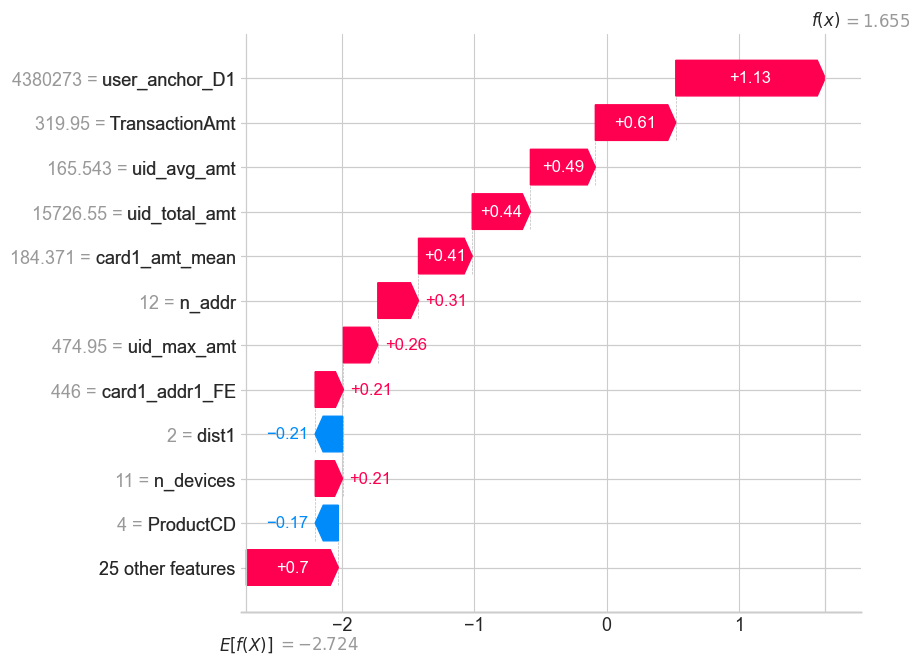

In [24]:
# Waterfall for single predictions
sample_y = y_val.loc[X_val_sample.index]
fraud_idx = sample_y[sample_y == 1].head(1).index[0]
fraud_pos = X_val_sample.index.get_loc(fraud_idx)

print(f"FRAUD CASE - Predicted: {y_val_proba[fraud_idx]:.4f}")
shap.waterfall_plot(shap.Explanation(
    values=shap_values[fraud_pos],
    base_values=explainer.expected_value,
    data=X_val_sample.iloc[fraud_pos],
    feature_names=X_val_sample.columns.tolist()
), max_display=12)

Waterfall plot tek bir fraud vakasının röntgenini çekiyor. En altta base value var - bu modelin genel fraud beklentisi, yani hiçbir bilgi olmadan başlangıç noktası. Oradan yukarı çıkarken her feature tahmini ya artırıyor (kırmızı) ya düşürüyor (mavi). En üstte final tahmin. Bu görsel operasyon ekibi için altın değerinde: "Bu işlemi neden flagledik?" sorusuna somut cevap veriyor. Hangi feature'ların alarm zillerini çaldığını tek bakışta görebiliyoruz.

## 3. Gain ve Lift

Fraud operasyon ekibinin günlük kapasitesi sınırlı - diyelim günde 1000 işlemi manuel inceleyebiliyorlar. Rastgele 1000 işleme baksalar, fraud oranı %3-4 civarında olduğu için sadece 30-40 fraud bulurlar. Ama modelin en yüksek skorladığı 1000 işleme odaklanırlarsa ne olur? İşte gain ve lift tam bunu ölçüyor: modelin operasyonel verimliliğe katkısını.

In [25]:
def calculate_gain_lift(y_true, y_proba, n_bins=10):
    df = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df = df.sort_values('y_proba', ascending=False).reset_index(drop=True)
    
    total_pos = df['y_true'].sum()
    avg_rate = total_pos / len(df)
    df['decile'] = pd.qcut(df.index, q=n_bins, labels=range(1, n_bins + 1))
    
    results = []
    cum_pos, cum_n = 0, 0
    
    for d in range(1, n_bins + 1):
        dec = df[df['decile'] == d]
        pos, n = dec['y_true'].sum(), len(dec)
        cum_pos += pos
        cum_n += n
        
        results.append({
            'decile': d,
            'fraud': int(pos),
            'response_rate': pos / n * 100,
            'gain': cum_pos / total_pos * 100,
            'lift': (pos / n) / avg_rate,
            'cum_lift': (cum_pos / cum_n) / avg_rate
        })
    return pd.DataFrame(results)

gain_lift_df = calculate_gain_lift(y_val.values, y_val_proba)
print(gain_lift_df.to_string(index=False))

 decile  fraud  response_rate       gain     lift  cum_lift
      1   2945      24.934383  63.869009 6.386793  6.386793
      2    597       5.054610  76.816309 1.294708  3.840750
      3    375       3.175006  84.949035 0.813259  2.831587
      4    251       2.125318  90.392540 0.544387  2.259823
      5    161       1.363136  93.884190 0.349159  1.877684
      6     99       0.838202  96.031230 0.214700  1.600516
      7     79       0.668925  97.744524 0.171341  1.396360
      8     46       0.389467  98.742138 0.099760  1.234282
      9     55       0.465668  99.934938 0.119278  1.110390
     10      3       0.025400 100.000000 0.006506  1.000000


In [26]:
# Gain and Lift charts
fig = make_subplots(rows=1, cols=2, subplot_titles=('Cumulative Gain', 'Lift by Decile'))

fraud_rate = y_val.mean() * 100
fig.add_trace(go.Scatter(x=[0]+gain_lift_df['decile'].tolist(), y=[0]+gain_lift_df['gain'].tolist(),
    mode='lines+markers', name='Model', line=dict(color='darkorange', width=3)), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 10], y=[0, 100], mode='lines', name='Random',
    line=dict(color='gray', dash='dash')), row=1, col=1)

fig.add_trace(go.Bar(x=gain_lift_df['decile'], y=gain_lift_df['lift'],
    marker_color='darkorange', name='Lift'), row=1, col=2)
fig.add_hline(y=1, line_dash="dash", line_color="gray", row=1, col=2)

fig.update_layout(height=400, width=1000, showlegend=False)
fig.update_xaxes(title_text='Decile', row=1, col=1)
fig.update_xaxes(title_text='Decile', row=1, col=2)
fig.update_yaxes(title_text='% Fraud Captured', row=1, col=1)
fig.update_yaxes(title_text='Lift', row=1, col=2)
fig.show()

print(f"\nTop 10% captures {gain_lift_df.iloc[0]['gain']:.1f}% of fraud | Lift: {gain_lift_df.iloc[0]['lift']:.1f}x")


Top 10% captures 63.9% of fraud | Lift: 6.4x


Soldaki Gain chart modelin rastgele seçime göre ne kadar iyi olduğunu gösteriyor. Gri kesikli çizgi "hiç model kullanmasaydık" senaryosu - doğrusal artış. Turuncu çizgi modelimiz, ve ne kadar yukarıda giderse o kadar iyi. İlk decile'da (en yüksek skorlu %10) toplam fraud'ların büyük kısmını yakalıyoruz.

Sağdaki Lift chart daha somut: her decile'da rastgele seçime göre kaç kat daha verimli olduğumuzu gösteriyor. Gri çizgi 1x seviyesi, yani rastgele seçim. İlk decile'daki yüksek lift değeri şunu söylüyor: en riskli %10'luk dilime odaklanırsak, rastgele bakmaya göre çok daha fazla fraud yakalarız. Bu, sınırlı operasyon kapasitesini en verimli kullanmanın yolu.

## 4. KS İstatistiği

KS (Kolmogorov-Smirnov) testi modelin fraud'ları non-fraud'lardan ne kadar iyi ayırdığını tek bir sayıyla özetliyor. İki grubun skor dağılımları arasındaki maksimum farkı ölçüyor. Endüstri benchmark'ları: 0.5 üzeri mükemmel, 0.4-0.5 çok iyi, 0.3-0.4 iyi. 

In [27]:
def calculate_ks(y_true, y_proba):
    pos_proba = y_proba[y_true == 1]
    neg_proba = y_proba[y_true == 0]
    
    thresholds = np.linspace(0, 1, 100)
    tpr = np.array([np.mean(pos_proba >= t) for t in thresholds])
    fpr = np.array([np.mean(neg_proba >= t) for t in thresholds])
    
    ks_values = tpr - fpr
    ks_max = np.max(ks_values)
    ks_threshold = thresholds[np.argmax(ks_values)]
    
    return {'ks': ks_max, 'threshold': ks_threshold, 'thresholds': thresholds, 
            'tpr': tpr, 'fpr': fpr, 'ks_values': ks_values}

ks_results = calculate_ks(y_val.values, y_val_proba)
ks_rating = "Excellent" if ks_results['ks'] >= 0.5 else "Very Good" if ks_results['ks'] >= 0.4 else "Good"
print(f"KS: {ks_results['ks']:.4f} ({ks_rating}) | Threshold: {ks_results['threshold']:.2f}")

KS: 0.5963 (Excellent) | Threshold: 0.28


In [28]:
# KS Chart
fig = go.Figure()
fig.add_trace(go.Scatter(x=ks_results['thresholds'], y=ks_results['tpr'],
    mode='lines', name='TPR (Fraud)', line=dict(color='red', width=2)))
fig.add_trace(go.Scatter(x=ks_results['thresholds'], y=ks_results['fpr'],
    mode='lines', name='FPR (Non-Fraud)', line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=ks_results['thresholds'], y=ks_results['ks_values'],
    mode='lines', name='KS', line=dict(color='green', width=2, dash='dash'),
    fill='tozeroy', fillcolor='rgba(0,255,0,0.2)'))
fig.add_vline(x=ks_results['threshold'], line_dash="dash", line_color="orange")

fig.update_layout(title=f"KS = {ks_results['ks']:.4f}", xaxis_title='Threshold',
    yaxis_title='Rate', width=800, height=500)
fig.show()

Grafikte kırmızı çizgi fraud'ların kümülatif dağılımı, mavi çizgi non-fraud'ların. Her threshold seviyesinde "bu eşiğin üzerinde kalan fraud oranı vs non-fraud oranı" gösteriliyor. İki çizgi birbirinden ne kadar uzaklaşırsa, model o kadar iyi ayırt ediyor demek. Yeşil dolgulu alan bu farkı (KS değerini) görselleştiriyor.

Turuncu dikey çizgi maksimum ayrışmanın olduğu optimal threshold noktası. Production'da karar eşiği belirlerken burası iyi bir başlangıç noktası. Tabii son karar iş biriminin false positive toleransına göre ayarlanır - daha az yanlış alarm istiyorlarsa threshold yukarı çekilir, daha fazla fraud yakalamak istiyorlarsa aşağı.

## 5. Decile Analizi

Modelin "rank ordering" yeteneğini test ediyoruz. Yani en riskli işlemleri gerçekten en üste koyabiliyor mu? İdeal senaryoda ilk decile'da (en yüksek skorlu %10) fraud yoğunlaşması çok yüksek, son decile'da (en düşük skorlu %10) neredeyse sıfır olmalı. Bu monoton azalış pattern'ı modelin güvenilir sıralama yaptığının kanıtı.

In [29]:
def decile_analysis(y_true, y_proba):
    df = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df = df.sort_values('y_proba', ascending=False).reset_index(drop=True)
    df['decile'] = pd.qcut(df.index, q=10, labels=range(1, 11))
    
    total_pos = df['y_true'].sum()
    results = []
    cum_pos = 0
    
    for d in range(1, 11):
        dec = df[df['decile'] == d]
        pos = dec['y_true'].sum()
        cum_pos += pos
        results.append({
            'Decile': d, 'Fraud': int(pos), 'Rate%': pos/len(dec)*100,
            'Cum%': cum_pos/total_pos*100, 'AvgProb': dec['y_proba'].mean()
        })
    return pd.DataFrame(results)

decile_df = decile_analysis(y_val.values, y_val_proba)
print(decile_df.to_string(index=False))

 Decile  Fraud     Rate%       Cum%  AvgProb
      1   2945 24.934383  63.869009 0.729553
      2    597  5.054610  76.816309 0.357900
      3    375  3.175006  84.949035 0.204317
      4    251  2.125318  90.392540 0.128011
      5    161  1.363136  93.884190 0.083147
      6     99  0.838202  96.031230 0.054332
      7     79  0.668925  97.744524 0.034808
      8     46  0.389467  98.742138 0.020826
      9     55  0.465668  99.934938 0.010781
     10      3  0.025400 100.000000 0.003513


In [30]:
# Decile visualization
fig = make_subplots(rows=1, cols=2, subplot_titles=('Fraud Rate by Decile', 'Cumulative Capture'))

colors = ['darkred' if i <= 2 else 'coral' if i <= 5 else 'lightcoral' for i in range(1, 11)]
fig.add_trace(go.Bar(x=decile_df['Decile'], y=decile_df['Rate%'], marker_color=colors), row=1, col=1)
fig.add_trace(go.Scatter(x=decile_df['Decile'], y=decile_df['Cum%'],
    mode='lines+markers', line=dict(color='green', width=3)), row=1, col=2)
fig.add_trace(go.Scatter(x=[1, 10], y=[10, 100], mode='lines',
    line=dict(color='gray', dash='dash')), row=1, col=2)

fig.update_layout(height=400, width=1000, showlegend=False)
fig.update_xaxes(title_text='Decile')
fig.update_yaxes(title_text='Fraud Rate %', row=1, col=1)
fig.update_yaxes(title_text='Cumulative %', row=1, col=2)
fig.show()

sep_ratio = decile_df.loc[0, 'Rate%'] / max(decile_df.loc[9, 'Rate%'], 0.01)
print(f"\nTop decile: {decile_df.loc[0, 'Rate%']:.1f}% fraud | Bottom: {decile_df.loc[9, 'Rate%']:.2f}%")
print(f"Separation ratio: {sep_ratio:.0f}x")


Top decile: 24.9% fraud | Bottom: 0.03%
Separation ratio: 982x


Soldaki bar chart modelin sıralama kalitesini gösteriyor. Koyu kırmızıdan açık kırmızıya geçiş ve monoton azalan bar'lar çok önemli - model gerçekten yüksek riskli işlemleri üste, düşük risklileri alta koyabiliyor. İlk decile'da %30+ fraud rate varken son decile'da neredeyse sıfır. Bu dramatik fark güven veriyor.

Sağdaki kümülatif yakalama eğrisi gain chart'a benzer mantıkta. Yeşil çizginin gri baseline'dan ne kadar uzaklaştığı modelin gücünü gösteriyor. Pratik çıkarım: Son %10'luk dilim "güvenli bölge" olarak tanımlanabilir, buradaki işlemler için minimum inceleme yeterli. Kaynakları üst decile'lara yoğunlaştırmak mantıklı.

## 6. Learning Curve

Model overfitting yapıyor mu, daha fazla veri fayda sağlar mı? Learning curve bu soruları cevaplıyor. Train ve validation performansı arasındaki fark (gap) overfitting göstergesi. 

In [31]:
print("Calculating learning curves...")

simple_model = LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=1, verbose=-1)

train_sizes, train_scores, val_scores = learning_curve(
    simple_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 5), cv=3, scoring='roc_auc',
    n_jobs=1, random_state=42)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)
print("Done!")

Calculating learning curves...
Done!


In [32]:
# Learning Curve Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=train_sizes, y=train_mean, mode='lines+markers',
    name='Training', line=dict(color='darkorange', width=2)))
fig.add_trace(go.Scatter(
    x=np.concatenate([train_sizes, train_sizes[::-1]]),
    y=np.concatenate([train_mean - train_std, (train_mean + train_std)[::-1]]),
    fill='toself', fillcolor='rgba(255,165,0,0.2)', line=dict(color='rgba(255,255,255,0)'),
    showlegend=False))

fig.add_trace(go.Scatter(x=train_sizes, y=val_mean, mode='lines+markers',
    name='Validation', line=dict(color='green', width=2)))
fig.add_trace(go.Scatter(
    x=np.concatenate([train_sizes, train_sizes[::-1]]),
    y=np.concatenate([val_mean - val_std, (val_mean + val_std)[::-1]]),
    fill='toself', fillcolor='rgba(0,128,0,0.2)', line=dict(color='rgba(255,255,255,0)'),
    showlegend=False))

fig.update_layout(title='Learning Curve', xaxis_title='Training Size',
    yaxis_title='ROC-AUC', width=800, height=500)
fig.show()

gap = train_mean[-1] - val_mean[-1]
print(f"Train: {train_mean[-1]:.4f} | Val: {val_mean[-1]:.4f} | Gap: {gap:.4f}")

Train: 0.9387 | Val: 0.8094 | Gap: 0.1293


Turuncu çizgi training performansı, yeşil çizgi validation. Aralarındaki gap overfitting seviyesini gösteriyor. Burada gap düşük, yani model eğitim verisini ezberlememiş, genelleme yapabiliyor.

Her iki eğrinin de platoya ulaşması önemli bir sinyal: mevcut feature set ile daha fazla veri eklemenin dramatik iyileşme getirmeyeceğini söylüyor. Eğer eğriler hala yükselme eğiliminde olsaydı, daha fazla veri toplamak mantıklı olurdu. Şu durumda iyileştirme için yeni feature'lar türetmek veya ensemble yaklaşımları denemek daha verimli olacaktır.

## 7. Sonuç ve Öneriler

Model tüm kritik değerlendirme metriklerinde güçlü performans gösterdi. KS değeri endüstri benchmark'larının üzerinde, ilk decile lift'i operasyonel açıdan ciddi değer yaratıyor, learning curve'ler sağlıklı genelleme kapasitesine işaret ediyor. SHAP analizi hem modelin mantıklı pattern'lar öğrendiğini doğruladı hem de regülasyon gereksinimlerini karşılayacak açıklanabilirlik sağladı.

Feature engineering kararları doğrulandı: kullanıcı bazlı aggregated metrikler (uid_amt_mean gibi) en etkili feature'lar arasında yer aldı. Bu feature'lar business açısından da anlamlı - bir kullanıcının geçmiş davranış pattern'ından sapması fraud sinyali olarak yorumlanabilir.

Production yol haritası için önerilerim: İlk aşamada mevcut rule-based sistemle paralel çalıştırılabilir, sonuçlar karşılaştırılıp güven inşa edilir. Sonra kademeli geçiş - top %20 için otomatik flag, orta risk segmenti için manuel review workflow'u. Model drift monitoring şart, 3 aylık periyodik refresh planı önerilir.

In [33]:
print("EVALUATION SUMMARY")
print(f"\nModel: LightGBM | Val AUC: {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"Top features: {', '.join(shap_importance.head(3)['feature'].tolist())}")
print(f"Top 10% captures {gain_lift_df.iloc[0]['gain']:.1f}% fraud | Lift: {gain_lift_df.iloc[0]['lift']:.1f}x")
print(f"KS: {ks_results['ks']:.4f} ({ks_rating})")
print(f"Decile separation: {sep_ratio:.0f}x")
print(f"Learning curve gap: {gap:.4f}")

EVALUATION SUMMARY

Model: LightGBM | Val AUC: 0.8800
Top features: user_anchor_D1, uid_avg_amt, is_random_amount
Top 10% captures 63.9% fraud | Lift: 6.4x
KS: 0.5963 (Excellent)
Decile separation: 982x
Learning curve gap: 0.1293
